In [1]:
import os
from typing import TypedDict, List

from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma
from langchain_groq import ChatGroq

from langgraph.graph import StateGraph, START, END

from dotenv import load_dotenv


C:\Users\new\AppData\Local\Temp\ipykernel_34496\1049881508.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader
e:\Summer-2026-projects\Langgraph-practice\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
loader = PyPDFLoader("About_khan.pdf")

documents = loader.load()

print("PDF pages:", len(documents))

PDF pages: 107


In [4]:
# ============================================================
# 2. SPLIT DOCUMENTS
# ============================================================

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = splitter.split_documents(documents)

print("Total chunks:", len(chunks))



Total chunks: 359


In [5]:
# ============================================================
# 3. EMBEDDINGS
# ============================================================

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1461.83it/s]


In [6]:
# ============================================================
# 4. CHROMA VECTOR STORE
# ============================================================

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory="./chroma_db_self_rag"
)

In [7]:

# ============================================================
# 5. RETRIEVER
# ============================================================

retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={
        "k": 5
    }
)

In [8]:
# ============================================================
# 6. GROQ LLM
# ============================================================

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

In [9]:
# ============================================================
# 7. SELF-RAG STATE
# ============================================================

class SelfRAGState(TypedDict, total=False):

    # User question
    question: str

    # Query used for retrieval
    search_query: str

    # Retrieval decision
    retrieve_decision: str

    # Retrieved documents
    retrieved_docs: List

    # Relevant documents
    relevant_docs: List

    # Generated answer
    answer: str

    # Reflection decisions
    support_decision: str
    usefulness_decision: str

    # Counters
    retry_count: int
    revision_count: int


In [10]:


# ============================================================
# 8. STRUCTURED OUTPUT SCHEMAS
# ============================================================

class RetrievalDecision(BaseModel):

    decision: str = Field(
        description="Return only yes or no."
    )


class RelevanceGrade(BaseModel):

    relevant: str = Field(
        description="Return only yes or no."
    )


class SupportGrade(BaseModel):

    support: str = Field(
        description="Return yes, partial, or no."
    )


class UsefulnessGrade(BaseModel):

    useful: str = Field(
        description="Return only yes or no."
    )


class QueryRewrite(BaseModel):

    query: str = Field(
        description="Return an improved search query."
    )


In [29]:
# ============================================================
# 9. STRUCTURED LLMs
# ============================================================

retrieval_grader = llm.with_structured_output(
    RetrievalDecision,
    method="json_schema",
    strict=True
)
relevance_grader = llm.with_structured_output(
    RelevanceGrade,
    method="json_schema",
    strict=True
)

support_grader = llm.with_structured_output(
    SupportGrade,
    method="json_schema",
    strict=True
)

usefulness_grader = llm.with_structured_output(
    UsefulnessGrade,
    method="json_schema",
    strict=True
)


query_rewriter = llm.with_structured_output(
    QueryRewrite,
    method="json_schema",
    strict=True
)

In [12]:

# ============================================================
# 10. DECIDE WHETHER RETRIEVAL IS NEEDED
# ============================================================

def decide_retrieval(state: SelfRAGState):

    question = state["question"]

    prompt = f"""
You are a retrieval decision system.

User question:
{question}

Decide whether the question requires information
from the provided knowledge base.

Return:
- yes = retrieval is needed
- no = retrieval is not needed

Return only the structured decision.
"""

    result = retrieval_grader.invoke(prompt)

    decision = result.decision.lower().strip()

    print("\n================ RETRIEVAL DECISION ================")
    print("Decision:", decision)

    return {
        "retrieve_decision": decision,
        "search_query": question
    }

In [13]:
# ============================================================
# 11. ROUTE AFTER RETRIEVAL DECISION
# ============================================================

def route_retrieval(state: SelfRAGState):

    if state["retrieve_decision"] == "yes":
        return "retrieve"

    return "generate_direct"


In [14]:
# ============================================================
# 12. RETRIEVE DOCUMENTS
# ============================================================

def retrieve(state: SelfRAGState):

    query = state.get(
        "search_query",
        state["question"]
    )

    docs = retriever.invoke(query)

    print("\n================ RETRIEVE ================")
    print("Query:", query)
    print("Retrieved documents:", len(docs))

    return {
        "retrieved_docs": docs
    }


In [15]:
# ============================================================
# 13. CHECK DOCUMENT RELEVANCE
# ============================================================

def check_relevance(state: SelfRAGState):

    question = state["question"]

    docs = state.get(
        "retrieved_docs",
        []
    )

    relevant_docs = []

    print("\n================ RELEVANCE CHECK ================")

    for i, doc in enumerate(docs):

        prompt = f"""
You are a document relevance evaluator.

User question:
{question}

Document:
{doc.page_content}

Determine whether this document contains
information useful for answering the question.

Return:
- yes
- no

Return only the structured decision.
"""

        result = relevance_grader.invoke(prompt)

        relevance = result.relevant.lower().strip()

        print(
            f"Document {i + 1}: {relevance}"
        )

        if relevance == "yes":

            relevant_docs.append(doc)

    print(
        "Relevant documents:",
        len(relevant_docs)
    )

    return {
        "relevant_docs": relevant_docs
    }



In [16]:
# ============================================================
# 14. ROUTE AFTER RELEVANCE
# ============================================================

def route_after_relevance(state: SelfRAGState):

    relevant_docs = state.get(
        "relevant_docs",
        []
    )

    if len(relevant_docs) > 0:

        return "generate_from_context"

    return "rewrite_question"

In [17]:
# ============================================================
# 15. GENERATE DIRECT ANSWER
# ============================================================

def generate_direct(state: SelfRAGState):

    question = state["question"]

    prompt = f"""
Answer the user's question directly.

Question:
{question}

Rules:
- Answer clearly.
- Do not invent facts.
- If you are uncertain, say so.
"""

    response = llm.invoke(prompt)

    answer = response.content

    print("\n================ DIRECT GENERATION ================")
    print(answer)

    return {
        "answer": answer
    }


In [18]:
# ============================================================
# 16. GENERATE ANSWER FROM RETRIEVED CONTEXT
# ============================================================

def generate_from_context(state: SelfRAGState):

    question = state["question"]

    docs = state.get(
        "relevant_docs",
        []
    )

    context = "\n\n".join(
        doc.page_content
        for doc in docs
    )

    prompt = f"""
Answer the user's question using the provided context.

Question:
{question}

Context:
{context}

Rules:
- Use the context as the primary source.
- Do not invent information.
- Do not add unsupported facts.
- Give a clear and useful answer.
"""

    response = llm.invoke(prompt)

    answer = response.content

    print("\n================ CONTEXT GENERATION ================")
    print(answer)

    return {
        "answer": answer
    }


In [19]:
# ============================================================
# 17. CHECK ANSWER SUPPORT
# ============================================================

def check_support(state: SelfRAGState):

    question = state["question"]

    answer = state["answer"]

    docs = state.get(
        "relevant_docs",
        []
    )

    context = "\n\n".join(
        doc.page_content
        for doc in docs
    )

    prompt = f"""
You are a factuality evaluator.

Question:
{question}

Context:
{context}

Generated answer:
{answer}

Determine whether the generated answer
is supported by the context.

Return:
- yes = fully supported
- partial = partially supported
- no = not supported

Return only the structured decision.
"""

    result = support_grader.invoke(prompt)

    support = result.support.lower().strip()

    print("\n================ SUPPORT CHECK ================")
    print("Support:", support)

    return {
        "support_decision": support
    }


In [20]:
# ============================================================
# 18. ROUTE AFTER SUPPORT
# ============================================================

def route_after_support(state: SelfRAGState):

    support = state["support_decision"]

    revision_count = state.get(
        "revision_count",
        0
    )

    retry_count = state.get(
        "retry_count",
        0
    )

    # Fully supported
    if support == "yes":

        return "is_use"


    # Partially supported
    if support == "partial":

        if revision_count < 2:
            return "revise_answer"

        return "is_use"


    # Unsupported answer
    if retry_count < 2:

        return "rewrite_question"


    return "no_answer_found"


In [21]:
# ============================================================
# 19. CHECK ANSWER USEFULNESS
# ============================================================

def check_usefulness(state: SelfRAGState):

    question = state["question"]

    answer = state["answer"]

    prompt = f"""
You are an answer usefulness evaluator.

Question:
{question}

Answer:
{answer}

Determine whether the answer directly,
clearly, and sufficiently answers the question.

Return:
- yes
- no

Return only the structured decision.
"""

    result = usefulness_grader.invoke(prompt)

    useful = result.useful.lower().strip()

    print("\n================ USEFULNESS CHECK ================")
    print("Useful:", useful)

    return {
        "usefulness_decision": useful
    }


In [22]:
# ============================================================
# 20. ROUTE AFTER USEFULNESS
# ============================================================

def route_after_usefulness(state: SelfRAGState):

    useful = state["usefulness_decision"]

    if useful == "yes":

        return "end"

    revision_count = state.get(
        "revision_count",
        0
    )

    if revision_count < 2:

        return "revise_answer"

    return "no_answer_found"


In [23]:
# ============================================================
# 21. REVISE ANSWER
# ============================================================

def revise_answer(state: SelfRAGState):

    question = state["question"]

    old_answer = state["answer"]

    docs = state.get(
        "relevant_docs",
        []
    )

    context = "\n\n".join(
        doc.page_content
        for doc in docs
    )

    prompt = f"""
Improve the following answer.

Question:
{question}

Context:
{context}

Previous answer:
{old_answer}

Create a better answer.

Rules:
- Directly answer the question.
- Stay grounded in the context.
- Remove unsupported claims.
- Be clear and concise.
"""

    response = llm.invoke(prompt)

    revised_answer = response.content

    revision_count = state.get(
        "revision_count",
        0
    ) + 1

    print("\n================ REVISE ANSWER ================")
    print("Revision:", revision_count)
    print(revised_answer)

    return {
        "answer": revised_answer,
        "revision_count": revision_count
    }


In [24]:
# ============================================================
# 22. REWRITE QUESTION
# ============================================================

def rewrite_question(state: SelfRAGState):

    question = state["question"]

    old_query = state.get(
        "search_query",
        question
    )

    prompt = f"""
Rewrite the following search query to improve
retrieval quality.

Original user question:
{question}

Current search query:
{old_query}

Create a more specific and useful search query.

Return only the rewritten query.
"""

    result = query_rewriter.invoke(prompt)

    new_query = result.query.strip()

    retry_count = state.get(
        "retry_count",
        0
    ) + 1

    print("\n================ QUERY REWRITE ================")
    print("New query:", new_query)
    print("Retry:", retry_count)

    return {
        "search_query": new_query,
        "retry_count": retry_count
    }


In [25]:
def no_answer_found(state: SelfRAGState):

    print("\n================ NO RELIABLE ANSWER ================")

    return {
        "answer": (
            "I could not find enough reliable information "
            "to answer this question confidently."
        )
    }

In [26]:

# ============================================================
# 24. BUILD LANGGRAPH
# ============================================================

graph = StateGraph(SelfRAGState)


# ============================================================
# NODES
# ============================================================

graph.add_node(
    "decide_retrieval",
    decide_retrieval
)

graph.add_node(
    "retrieve",
    retrieve
)

graph.add_node(
    "is_relevant",
    check_relevance
)

graph.add_node(
    "generate_direct",
    generate_direct
)

graph.add_node(
    "generate_from_context",
    generate_from_context
)

graph.add_node(
    "is_sup",
    check_support
)

graph.add_node(
    "is_use",
    check_usefulness
)

graph.add_node(
    "revise_answer",
    revise_answer
)

graph.add_node(
    "rewrite_question",
    rewrite_question
)

graph.add_node(
    "no_answer_found",
    no_answer_found
)


# ============================================================
# START
# ============================================================

graph.add_edge(
    START,
    "decide_retrieval"
)


# ============================================================
# DECIDE RETRIEVAL
# ============================================================

graph.add_conditional_edges(
    "decide_retrieval",
    route_retrieval,
    {
        "retrieve": "retrieve",
        "generate_direct": "generate_direct"
    }
)


# ============================================================
# RETRIEVE → RELEVANCE
# ============================================================

graph.add_edge(
    "retrieve",
    "is_relevant"
)


# ============================================================
# RELEVANCE → GENERATE / REWRITE
# ============================================================

graph.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
        "rewrite_question": "rewrite_question"
    }
)


# ============================================================
# CONTEXT GENERATION → SUPPORT
# ============================================================

graph.add_edge(
    "generate_from_context",
    "is_sup"
)


# ============================================================
# SUPPORT → USE / REVISE / REWRITE
# ============================================================

graph.add_conditional_edges(
    "is_sup",
    route_after_support,
    {
        "is_use": "is_use",
        "revise_answer": "revise_answer",
        "rewrite_question": "rewrite_question",
        "no_answer_found": "no_answer_found"
    }
)


# ============================================================
# DIRECT GENERATION → USEFULNESS
# ============================================================

graph.add_edge(
    "generate_direct",
    "is_use"
)


# ============================================================
# USEFULNESS → END / REVISE
# ============================================================

graph.add_conditional_edges(
    "is_use",
    route_after_usefulness,
    {
        "end": END,
        "revise_answer": "revise_answer",
        "no_answer_found": "no_answer_found"
    }
)


# ============================================================
# REVISE → SUPPORT
# ============================================================

graph.add_edge(
    "revise_answer",
    "is_sup"
)


# ============================================================
# REWRITE → RETRIEVE
# ============================================================

graph.add_conditional_edges(
    "rewrite_question",
    lambda state: (
        "retrieve"
        if state.get("retry_count", 0) < 2
        else "no_answer_found"
    ),
    {
        "retrieve": "retrieve",
        "no_answer_found": "no_answer_found"
    }
)


# ============================================================
# NO ANSWER → END
# ============================================================

graph.add_edge(
    "no_answer_found",
    END
)


# ============================================================
# COMPILE
# ============================================================

app = graph.compile()


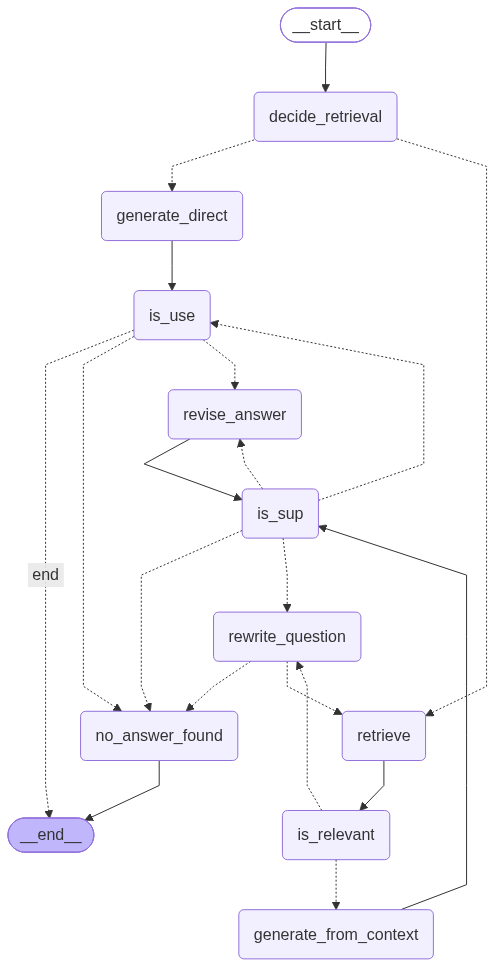

In [27]:
app

In [30]:
# ============================================================
# 25. CHAT LOOP
# ============================================================

while True:

    question = input("\nQuestion: ")

    if question.lower() in [
        "exit",
        "quit"
    ]:
        print("Goodbye!")
        break

    result = app.invoke({

        "question": question,

        "search_query": question,

        "retry_count": 0,

        "revision_count": 0
    })

    print("\n")
    print("=" * 70)
    print("FINAL ANSWER")
    print("=" * 70)

    print(
        result.get(
            "answer",
            "No answer generated."
        )
    )


================ RETRIEVAL DECISION ================
Decision: yes

================ RETRIEVE ================
Query: What about khan?
Retrieved documents: 5

================ RELEVANCE CHECK ================
Document 1: yes
Document 2: yes
Document 3: no
Document 4: yes
Document 5: yes
Relevant documents: 4

================ CONTEXT GENERATION ================
Bahawal Khan is a computer‑science student who is currently in his sixth semester of a BSc program at the University of Lahore. He has built a practical foundation across a wide range of topics—including Python programming, data science, machine‑learning, deep‑learning, natural‑language processing, backend development, databases, and modern generative‑AI systems—by working on project‑oriented learning rather than treating each technology in isolation.

**Key points about him from the provided material**

| Aspect | Details |
|--------|---------|
| **Academic background** | BSc in Computer Science, University of Lahore; coursewo